# 第3回 — 学習ループ + wandb

データ（第1回）とモデル（第2回）が揃ったので，**学習ループ**を書く．ここがチュートリアルの山場．
さらに **checkpoint 保存**と **wandb での記録**も行う．

**今日のゴール**: 学習が回り，loss が下がる曲線が出る（matplotlib / wandb）．

対象: `src/kws/train.py`, `configs/baseline.yaml`

> 参考: PyTorch 公式 "Optimization" https://docs.pytorch.org/tutorials/beginner/basics/optimization_tutorial.html
> / wandb https://docs.wandb.ai/models/integrations/pytorch

In [1]:
import os
from pathlib import Path
if Path.cwd().name == "notebooks":
    os.chdir("..")
import json
import torch
from torch import nn
from kws.data import get_dataloaders
from kws.model import AudioCNN
dev = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", dev)

device: cuda


## 1. 学習ループの肝はこの5行

1ステップの学習は必ずこの順番:

```
optimizer.zero_grad()   # ① 前回の勾配をリセット（PyTorchは勾配を溜め込むため）
logits = model(x)       # ② forward（予測）
loss = criterion(...)   # ③ 損失を計算
loss.backward()         # ④ backward（勾配を計算）
optimizer.step()        # ⑤ パラメータを更新
```

**なぜこの順か**: 勾配は累積するので毎回リセット(①)→計算(②③④)→更新(⑤)．
評価時は勾配不要なので `torch.no_grad()`（or `set_grad_enabled(False)`）で囲んで高速・省メモリにする．

## 2. 1 epoch を回す関数

train でも val でも使えるように，`optimizer` を渡したら学習，渡さなければ評価とする．
`model.train()` / `model.eval()` で BatchNorm 等の挙動が切り替わる点に注意．

In [2]:
from tqdm.auto import tqdm

def run_epoch(model, loader, criterion, device, optimizer=None, desc=""):
    is_train = optimizer is not None
    model.train(is_train)
    total, correct, loss_sum = 0, 0, 0.0
    for feats, targets in tqdm(loader, desc=desc, leave=False):
        feats, targets = feats.to(device), targets.to(device)
        with torch.set_grad_enabled(is_train):
            logits = model(feats)
            loss = criterion(logits, targets)
        if is_train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        loss_sum += loss.item() * targets.size(0)
        correct += (logits.argmax(1) == targets).sum().item()
        total += targets.size(0)
    return loss_sum / total, correct / total

/home/ymgt/ShiotaLab/B4_rinko_torchaudio/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3. train / val を分けて数 epoch 回す

`train` で学習し，`val`（学習に使わない）で汎化性能を見る．本来は 25 epoch ほど回すが，
notebook では雰囲気を見るため **2 epoch** だけ（本学習は後で CLI から）．

> 学習率(lr)はここでは **固定**（Adam, lr=1e-3）．学習の進行に合わせて lr を下げる
> **lr scheduler**（例: CosineAnnealing）もあり精度が伸びることが多い → 第5回で扱う．
> 一覧と解説（研究室まとめ）: https://github.com/tenk-9/pytorch_scheduler_list

In [3]:
loaders = get_dataloaders("data", batch_size=256, n_mels=64, num_workers=0)
model = AudioCNN(n_classes=35, base=32).to(dev)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

history = []
EPOCHS = 2
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(model, loaders["train"], criterion, dev, optimizer, f"E{epoch} train")
    va_loss, va_acc = run_epoch(model, loaders["val"],   criterion, dev, None,      f"E{epoch} val")
    print(f"epoch {epoch}: train_loss {tr_loss:.3f} acc {tr_acc:.3f} | val_loss {va_loss:.3f} acc {va_acc:.3f}")
    history.append({"epoch": epoch, "train_loss": tr_loss, "train_acc": tr_acc,
                    "val_loss": va_loss, "val_acc": va_acc})

E1 train:   0%|          | 0/331 [00:00<?, ?it/s]

E1 train:   0%|          | 1/331 [00:01<07:33,  1.37s/it]

E1 train:   1%|          | 2/331 [00:02<06:13,  1.14s/it]

E1 train:   1%|          | 3/331 [00:03<05:47,  1.06s/it]

E1 train:   1%|          | 4/331 [00:04<05:34,  1.02s/it]

...

E2 val:  92%|█████████▏| 36/39 [00:35<00:02,  1.06it/s]

E2 val:  95%|█████████▍| 37/39 [00:36<00:01,  1.07it/s]

E2 val:  97%|█████████▋| 38/39 [00:37<00:00,  1.07it/s]

E2 val: 100%|██████████| 39/39 [00:38<00:00,  1.07it/s]

epoch 2: train_loss 0.702 acc 0.841 | val_loss 0.619 acc 0.842


## 4. checkpoint: last.pt と best.pt

学習結果は保存しておく．2種類あると便利:
- **last.pt** … 毎エポックの「現在の重み」＋ optimizer/epoch → **中断しても再開**できる
- **best.pt** … val accuracy が最良だったエポックの重み → 推論・配布に使う

（最終 epoch が最良とは限らないので best を別に持つ）

In [4]:
def save_ckpt(path, model, optimizer, epoch, best_acc):
    torch.save({"model": model.state_dict(), "optimizer": optimizer.state_dict(),
                "epoch": epoch, "best_acc": best_acc}, path)

os.makedirs("exp/nb_demo", exist_ok=True)
best_acc = max(h["val_acc"] for h in history)
save_ckpt("exp/nb_demo/last.pt", model, optimizer, EPOCHS, best_acc)
save_ckpt("exp/nb_demo/best.pt", model, optimizer, EPOCHS, best_acc)
print("saved last.pt / best.pt  (best_acc=%.3f)" % best_acc)

saved last.pt / best.pt  (best_acc=0.842)


### 補足: early stopping と best-checkpoint

過学習（train は下がり続けるのに val が改善しなくなる）への対処に2つの考え方がある:

- **early stopping**: val が一定 epoch（patience）改善しなければ**学習を止める**．無駄な計算を省ける．
- **best-checkpoint（今回の方式）**: 学習は最後まで回し，その中の **val 最良の重み（best.pt）を採用**する．
  学習を止めないので「どこから過学習が始まるか」を曲線で観察できる．

このチュートリアルの baseline は **あえて early stopping せず**最後まで回す（best.pt は自動で最良を保持）．
これは過学習の様子を見せるためと，第5回で正則化や augmentation を入れて**改善する余地を残す**ため．
（early stopping 自体も第5回で試せる改善施策のひとつ）

## 5. ログ可視化 ①: history を matplotlib で描く

まずは中身が見える素直なやり方として，記録した `history` から loss / acc 曲線を描く．

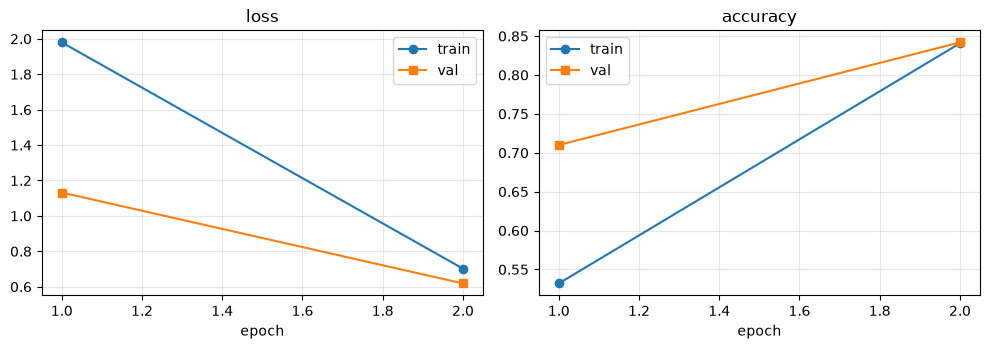

In [5]:
import matplotlib.pyplot as plt
ep = [h["epoch"] for h in history]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 3.6))
a1.plot(ep, [h["train_loss"] for h in history], "o-", label="train")
a1.plot(ep, [h["val_loss"] for h in history], "s-", label="val")
a1.set_title("loss"); a1.set_xlabel("epoch"); a1.legend(); a1.grid(alpha=.3)
a2.plot(ep, [h["train_acc"] for h in history], "o-", label="train")
a2.plot(ep, [h["val_acc"] for h in history], "s-", label="val")
a2.set_title("accuracy"); a2.set_xlabel("epoch"); a2.legend(); a2.grid(alpha=.3)
fig.tight_layout(); plt.show()

## 6. ログ可視化 ②: 同じことを wandb で

`wandb` を使うと `wandb.init` と `wandb.log` の **2 つの API** だけで自動可視化・run 比較ができる．
アカウントが無い／オフラインで試すなら `WANDB_MODE=offline` を設定する．

```python
import wandb
wandb.init(project="kws-tutorial", name="nb-demo", config={"lr": 1e-3})
for h in history:
    wandb.log(h)        # epoch ごとに記録 → ブラウザで loss 曲線が出る
wandb.finish()
```

下のセルはオフラインで実行（ローカルに wandb/ ディレクトリだけ作る）．

In [6]:
os.environ.setdefault("WANDB_MODE", "offline")
try:
    import wandb
    run = wandb.init(project="kws-tutorial", name="nb-demo", config={"lr": 1e-3, "base": 32})
    for h in history:
        wandb.log(h)
    wandb.finish()
    print("wandb にログした（offline: ./wandb/ に保存）")
except Exception as e:
    print("wandb スキップ:", e)

wandb: Tracking run with wandb version 0.27.2


wandb: W&B syncing is set to `offline` in this directory. Run `wandb online` or set WANDB_MODE=online to enable cloud syncing.
wandb: Run data is saved locally in /home/ymgt/ShiotaLab/B4_rinko_torchaudio/wandb/offline-run-20260616_192048-hgrigrcj


wandb: 
wandb: Run history:
wandb:      epoch ▁█
wandb:  train_acc ▁█
wandb: train_loss █▁
wandb:    val_acc ▁█
wandb:   val_loss █▁
wandb: 
wandb: Run summary:
wandb:      epoch 2
wandb:  train_acc 0.84074
wandb: train_loss 0.7022
wandb:    val_acc 0.8419
wandb:   val_loss 0.61861
wandb: 


wandb: You can sync this run to the cloud by running:
wandb: wandb sync /home/ymgt/ShiotaLab/B4_rinko_torchaudio/wandb/offline-run-20260616_192048-hgrigrcj


wandb: Find logs at: ./wandb/offline-run-20260616_192048-hgrigrcj/logs


wandb にログした（offline: ./wandb/ に保存）


## 7. 補足: 混合精度 AMP

精度には fp32 / fp16 / bf16 など色々あり，低精度で**省メモリ・高速化**する仕組みが
**AMP（Automatic Mixed Precision）**．`torch.autocast` + `GradScaler` で数行で入る．
学習ループの本質ではないので今回は深入りしない（興味があれば下のリンク）．

- bfloat16: https://en.wikipedia.org/wiki/Bfloat16_floating-point_format
- Google Cloud BFloat16: https://cloud.google.com/blog/products/ai-machine-learning/bfloat16-the-secret-to-high-performance-on-cloud-tpus
- PyTorch AMP recipe: https://docs.pytorch.org/tutorials/recipes/recipes/amp_recipe.html

## 8. 整理 → `src/kws/train.py` と本学習

学習ループを CLI 化して `src/kws/train.py` にまとめてある．config は素の YAML（`configs/baseline.yaml`）+
`dataclass`/`argparse` で読む（Hydra は名前だけ：大量の実験を回すなら便利という程度）．

本学習（25 epoch・configs/baseline.yaml）はノートではなくターミナルから:

```bash
uv run python -m kws.train --config configs/baseline.yaml --device cuda          # exp/baseline/ に成果物
uv run python -m kws.train --config configs/baseline.yaml --device cuda --resume # 中断したら last.pt から再開
```

解答: `git checkout ans -- src/kws/train.py`．次回（第4回）は学習済みモデルを **評価**する．